# Parametrsation of gemmae contours


## Documentation and Imports


Created on 27-05-2021

Author: Valentin Laplaud

This code loads gemmae contours from ShapeComputation2.ipynb and express them as a function of a curvilinar abcisse. Adding landmark points (notches and attach points) then allows a deformation of the contour to match the position of landmark points.

In [1]:
# plotting stuff
import matplotlib as mpl
mpl.use('TkAgg')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.path as mpltPath
from cycler import cycler
#Default colors
colorcycle = [plt.get_cmap('gist_rainbow')(1. * i/30) for i in range(30)]
mpl.rcParams['axes.prop_cycle'] = cycler(color=colorcycle)

# numbers handling
import numpy as np
import pandas as pd

# signal processing 
from scipy.signal import savgol_filter, correlate, correlation_lags
from scipy.interpolate import interp1d

# images handling
from skimage import io
from skimage.filters import threshold_otsu, gaussian, laplace, sobel
from skimage.measure import label, regionprops, regionprops_table
from skimage.util import invert
from skimage.morphology import binary_opening, binary_closing, remove_small_holes,binary_erosion
from skimage.color import rgb2gray
from skimage.segmentation import active_contour, morphological_geodesic_active_contour,morphological_chan_vese, checkerboard_level_set, inverse_gaussian_gradient
import cv2 as cv

# to hide known warnings
import warnings

# General system functions
import os
import shutil
import sys

import time

# my functions
sys.path.append('../')
import VallapFunc as vf


##  Define analysis functions

### Getting landmark points from first image using user input

In [2]:
def getImageCoordinates(P,s,npts,X,Y,Title): 
    
        RGBimg = io.imread(P + '\\' + s + '.tif', key = 1) # get the first image from tiff stack
        
        # ask user to click
        %matplotlib qt
        plt.figure(dpi=250)
        plt.title(Title)
        plt.imshow(RGBimg)
        plt.plot(X,Y,'c',lw = 0.5)
        pts = np.asarray(plt.ginput(npts, timeout=-1))
        plt.close()
        %matplotlib inline
        
        return(pts)
    
def getLandmarks(CD,GD,StackList,P):
        
        for s in StackList:

            Xcenter = GD.loc[(GD.index == s) & (GD['Img'] == 0) ,'Xcenter'].values
            Ycenter = GD.loc[(GD.index == s) & (GD['Img'] == 0) ,'Ycenter'].values
            
            Xcontour = CD.loc[(CD.index == s) & (CD['Img'] == 0) ,'Ximg'].values
            Ycontour = CD.loc[(CD.index == s) & (CD['Img'] == 0) ,'Yimg'].values
        
            NotchePts = getImageCoordinates(P,s,2,Xcontour,Ycontour,'Click on the two notches')
            AttachPt = getImageCoordinates(P,s,1,Xcontour,Ycontour,'Click on the attach point')

            RGBimg = io.imread(P + '\\' + s + '.tif', key = 1)
            
            plt.figure(dpi=250,facecolor='white')
            plt.suptitle('Attach point (magenta), notches (red), and center (blue) for alignement')
            plt.imshow(RGBimg)
            plt.plot(Xcontour,Ycontour,'c',lw = 0.5)
            plt.plot(NotchePts[0][0],NotchePts[0][1],'.r')
            plt.plot(NotchePts[1][0],NotchePts[1][1],'.r')
            plt.plot(AttachPt[0][0],AttachPt[0][1],'.m')
            plt.plot(Xcenter[0],Ycenter[0],'*b')
            plt.show()
            
        return(GD)

##  Enter data and run

### Data details

In [3]:
# Paths to data
P1 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.18'

P2 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.19'


# List of stacks to analyse

# experiments of 18-03-2021
StackList210318 = ['PPG1','PPG2','PPG3','PPG4','PPG6','PPG7','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22','PPG23','PPG24','PPG25','PPG26','PPG27','PPG28','PPG29']

            # No Rhizoid
StackList210318 = ['PPG2','PPG3','PPG6','PPG7','PPG9','PPG10','PPG11',
                   'PPG14','PPG15','PPG16','PPG18','PPG19',
                   'PPG22','PPG23','PPG24','PPG25','PPG26','PPG27','PPG28','PPG29']      

#StackList210318 = ['PPG2','PPG3'] # Tests



# experiments of 19-03-2021 (68h, cropped when air arrives, at least 52 images)
StackList210319 = ['PPG1','PPG2','PPG6','PPG8','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22']



#StackList210319 = ['PPG17','PPG1'] # Tests



print('Data choice made.')


Data choice made.


### Loading data 

In [4]:
## Expe 210318
ContourData210318 = pd.read_csv(P1 + '\\ContourData210318_Img.csv', index_col = 'Ind')
GlobalData210318 = pd.read_csv(P1 + '\\GlobalData210318_Img.csv', index_col = 'Ind')    

## Expe 210319
ContourData210319 = pd.read_csv(P2 + '\\ContourData210319_Img.csv', index_col = 'Ind')
GlobalData210319 = pd.read_csv(P2 + '\\GlobalData210319_Img.csv', index_col = 'Ind')

print('Loading OK.')

Loading OK.


## Test Zone

In [5]:
CD = ContourData210318[:]
GD = GlobalData210318[:]
StackTest = ['PPG7']
P = P1[:]

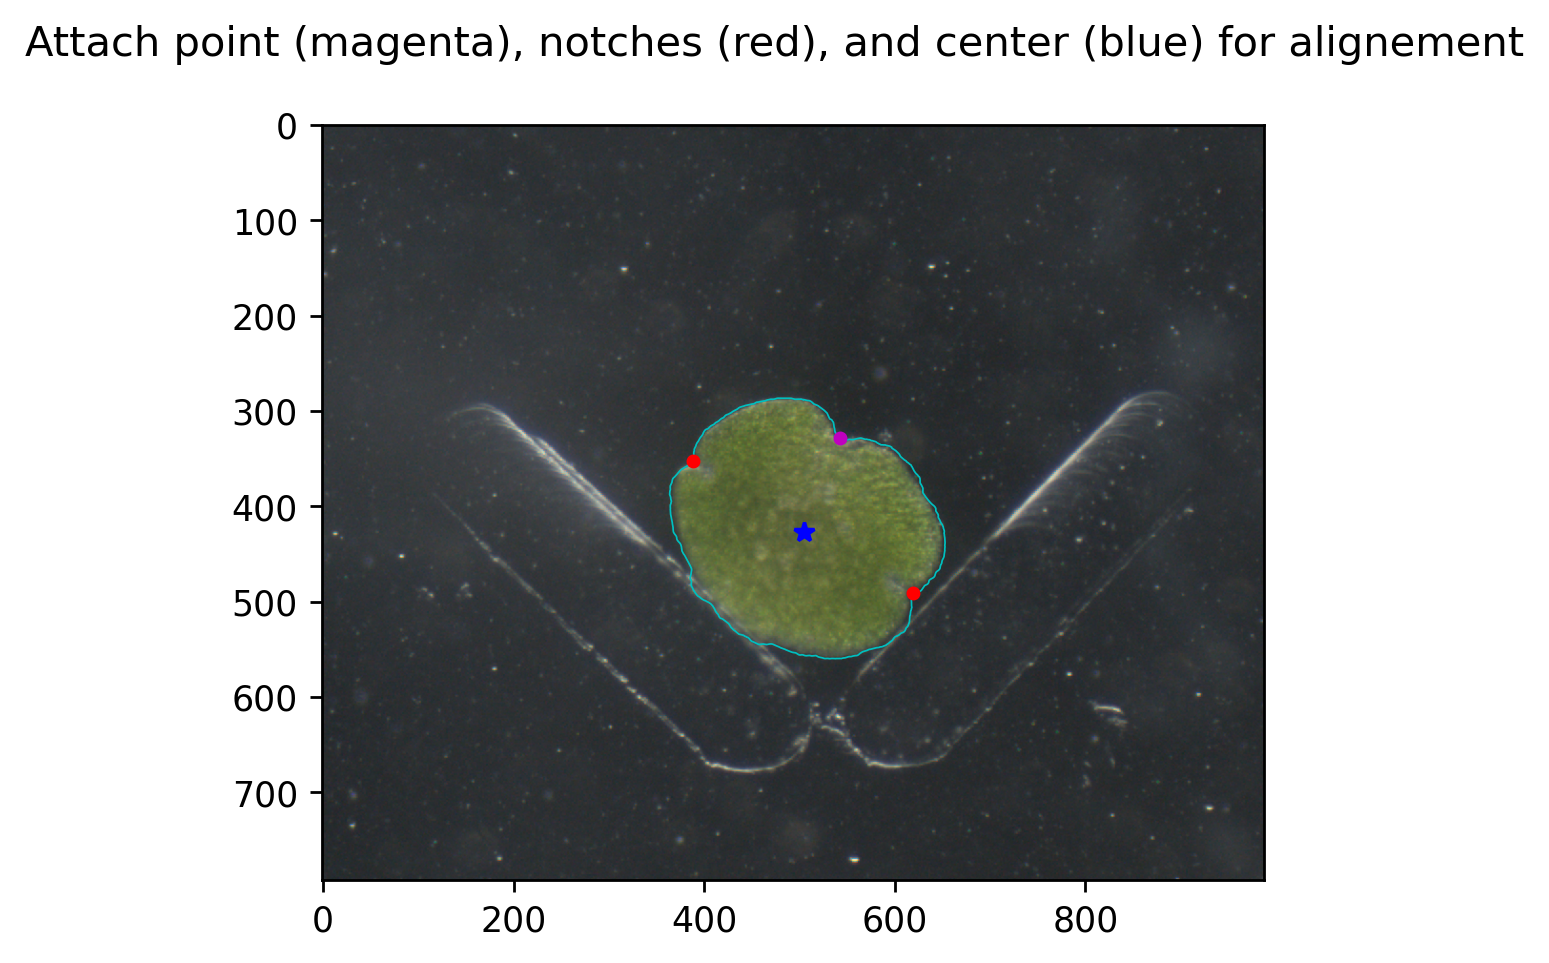

,Img,Time (min),FocusValue,GoodFocus,Area,Xcenter,Ycenter
Ind,,,,,,,
PPG7,0,0.0,19722.219608,True,293686.95905,504.697461,426.624758
PPG7,1,30.0,19936.313725,True,293689.53550,504.272079,426.302837
PPG7,2,60.0,20063.137255,True,294781.95030,504.237285,425.721595
PPG7,3,90.0,20288.039216,True,294052.81495,504.394052,425.300514
PPG7,4,120.0,20296.023529,True,295544.57950,504.123658,424.692934
PPG7,5,150.0,20293.654902,True,297139.40205,504.138738,424.073587
PPG7,6,180.0,20398.015686,True,299079.46890,504.255012,424.292407
PPG7,7,210.0,20447.396078,True,301483.29675,504.204541,423.577689
PPG7,8,240.0,20534.831373,True,304227.21600,504.449743,423.777092


In [6]:
getLandmarks(CD,GD,StackTest,P)

In [7]:
GD

,Img,Time (min),FocusValue,GoodFocus,Area,Xcenter,Ycenter
Ind,,,,,,,
PPG7,0,0.0,19722.219608,True,293686.95905,504.697461,426.624758
PPG7,1,30.0,19936.313725,True,293689.53550,504.272079,426.302837
PPG7,2,60.0,20063.137255,True,294781.95030,504.237285,425.721595
PPG7,3,90.0,20288.039216,True,294052.81495,504.394052,425.300514
PPG7,4,120.0,20296.023529,True,295544.57950,504.123658,424.692934
PPG7,5,150.0,20293.654902,True,297139.40205,504.138738,424.073587
PPG7,6,180.0,20398.015686,True,299079.46890,504.255012,424.292407
PPG7,7,210.0,20447.396078,True,301483.29675,504.204541,423.577689
PPG7,8,240.0,20534.831373,True,304227.21600,504.449743,423.777092
